In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error

In [4]:
df=pd.read_csv("retail_sales_dataset.csv")
print(df.head())

   Transaction ID        Date Customer ID  Gender  Age Product Category  \
0               1  2023-11-24     CUST001    Male   34           Beauty   
1               2  2023-02-27     CUST002  Female   26         Clothing   
2               3  2023-01-13     CUST003    Male   50      Electronics   
3               4  2023-05-21     CUST004    Male   37         Clothing   
4               5  2023-05-06     CUST005    Male   30           Beauty   

   Quantity  Price per Unit  Total Amount  
0         3              50           150  
1         2             500          1000  
2         1              30            30  
3         1             500           500  
4         2              50           100  


In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB
None


In [6]:
print(df.isnull().sum())
df.dropna(inplace=True)

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


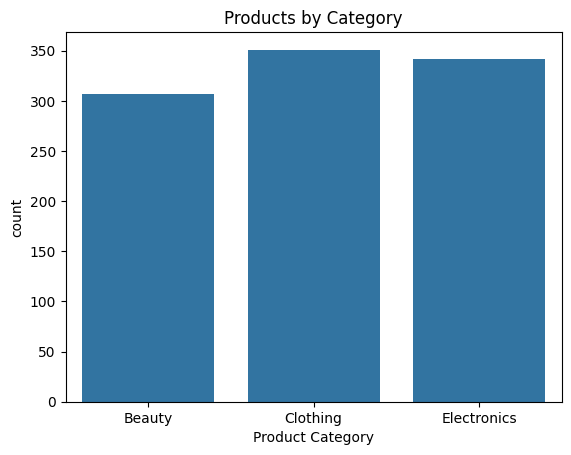

In [7]:
sns.countplot(x='Product Category', data=df)
plt.title("Products by Category")
plt.show()

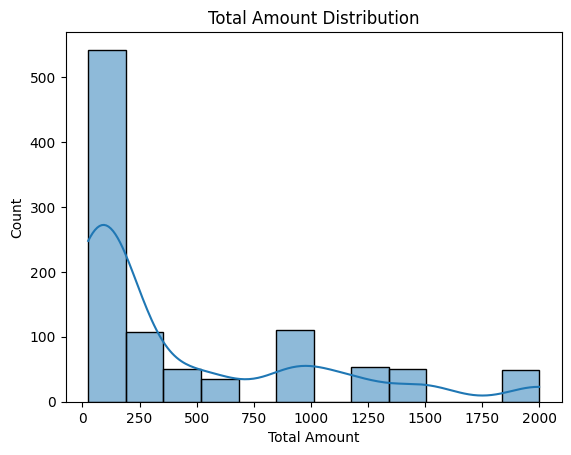

In [8]:
sns.histplot(df['Total Amount'], kde=True)
plt.title("Total Amount Distribution")
plt.show()

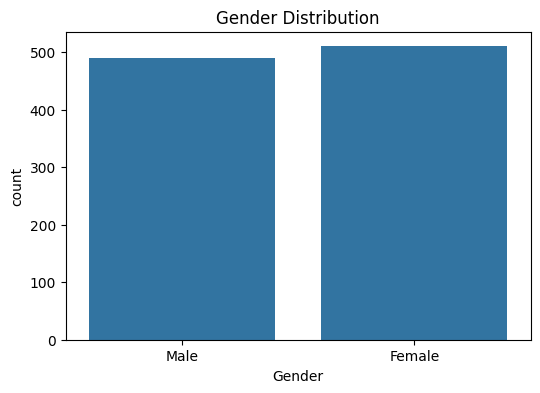

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution")
plt.show()

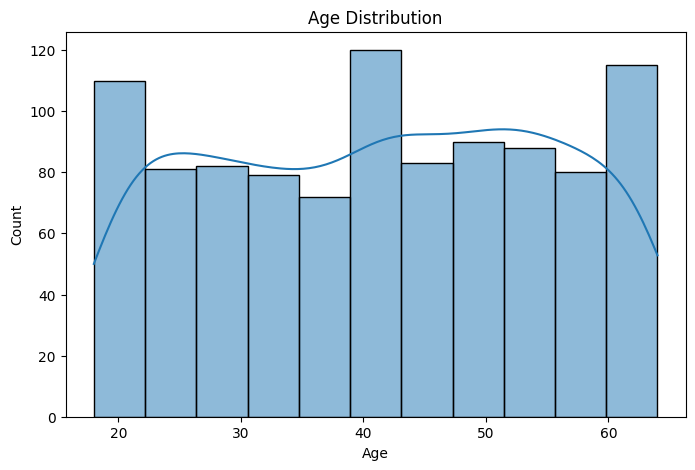

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution")
plt.show()


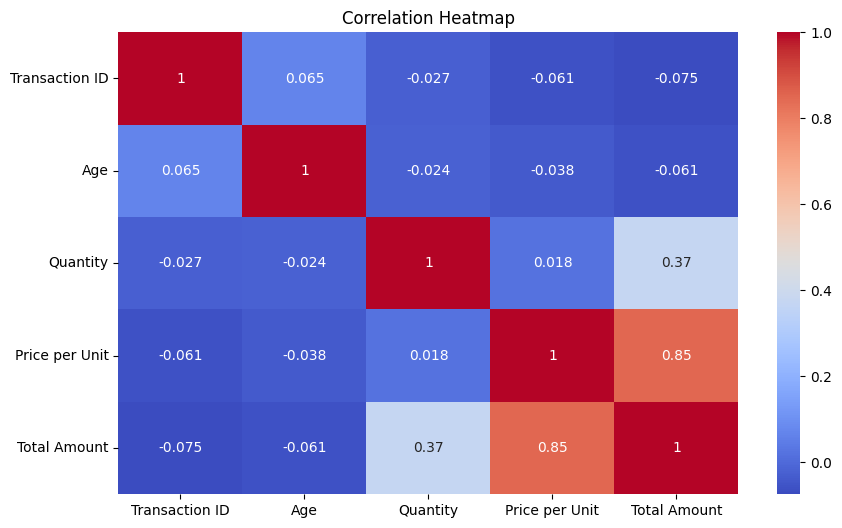

In [11]:
plt.figure(figsize=(10,6))
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


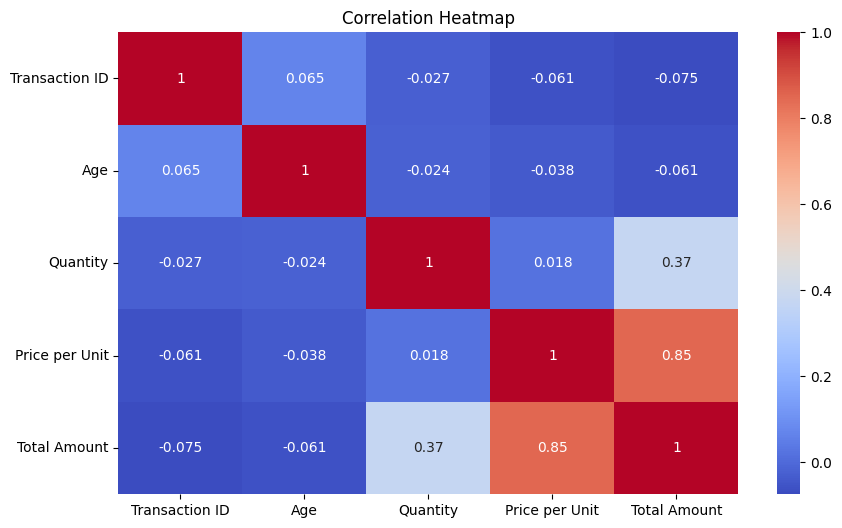

In [12]:
plt.figure(figsize=(10,6))
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


In [14]:

X = df[['Quantity', 'Price per Unit']]
y = df['Total Amount']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [15]:
predictions = model.predict(X_test)
print(predictions[:5])

[1344.97902338   44.77722781  487.46031934  342.08293242 1524.7548201 ]


In [18]:
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)
print("\nMean Absolute Error:", mae)
print("R2 Score:", r2)


Mean Absolute Error: 173.5729679280265
R2 Score: 0.8569981574765705


In [19]:
mse=mean_squared_error(y_test,predictions)
print("Mean Squared Error:",mse)

Mean Squared Error: 41860.81317288647


In [24]:
results=pd.DataFrame({"Actual":y_test,"Predicted":predictions})
print("\nPrediction Results")
print(results.head())


Prediction Results
     Actual    Predicted
521    1500  1344.979023
737     100    44.777228
740     300   487.460319
660     100   342.082932
411    2000  1524.754820


Observations:
Most customers belong to specific product categories.
Total sales vary based on quantity and unit price.
Some age groups contribute more to purchases.
Quantity and price per unit strongly influence total sales.
The Linear Regression model predicts sales with good accuracy.